In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
df=pd.read_csv(r"C:\Users\anant\OneDrive\Desktop\Mall_Customers.csv")
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [54]:
print(df.shape)

(200, 5)


In [55]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

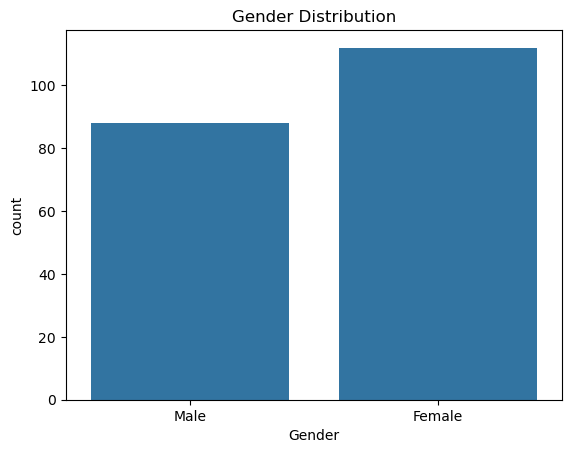

In [56]:
sns.countplot(data=df, x='Gender')
plt.title("Gender Distribution")
plt.show()


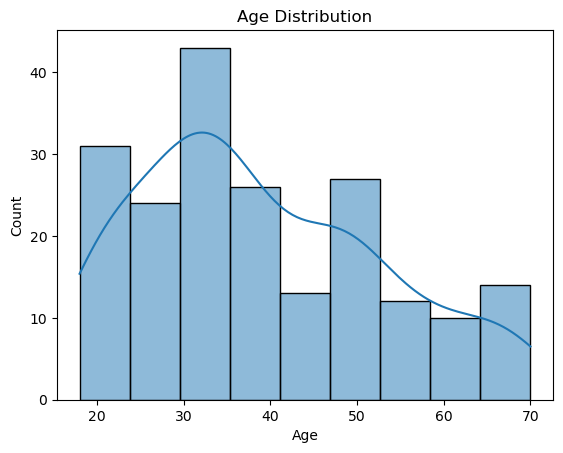

In [57]:
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution")
plt.show()


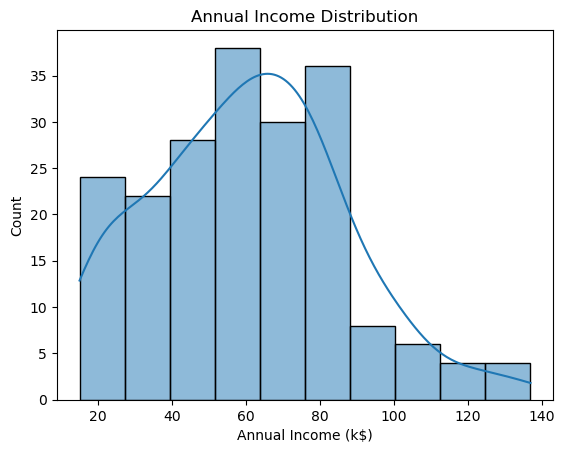

In [58]:
sns.histplot(df["Annual Income (k$)"], kde=True)
plt.title("Annual Income Distribution")
plt.show()


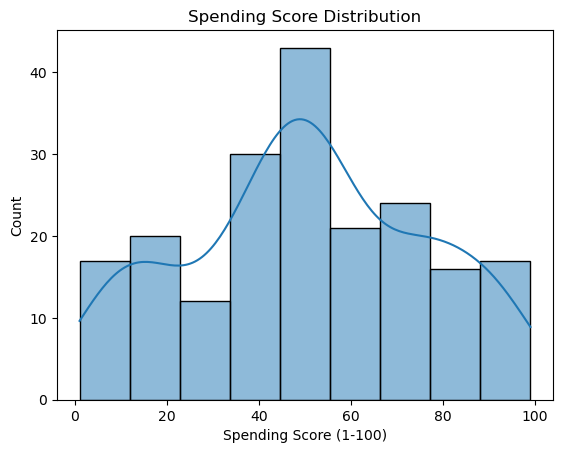

In [59]:
sns.histplot(df["Spending Score (1-100)"], kde=True)
plt.title("Spending Score Distribution")
plt.show()


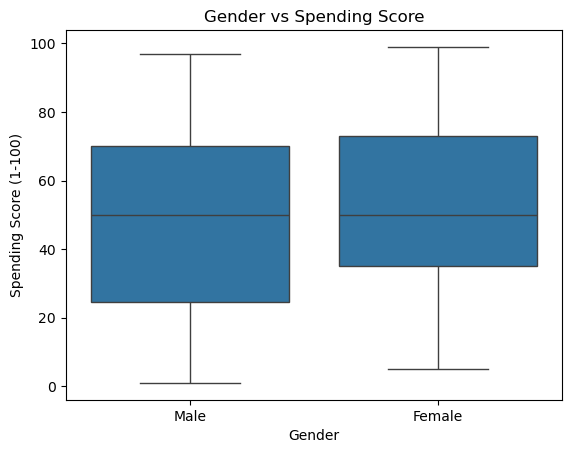

In [60]:
sns.boxplot(data=df, x="Gender", y="Spending Score (1-100)")
plt.title("Gender vs Spending Score")
plt.show()


In [61]:
df.drop(['Age', 'Gender','CustomerID'], axis=1, inplace=True)


In [62]:
df.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [63]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)


C:\Users\anant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\anant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\anant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\anant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

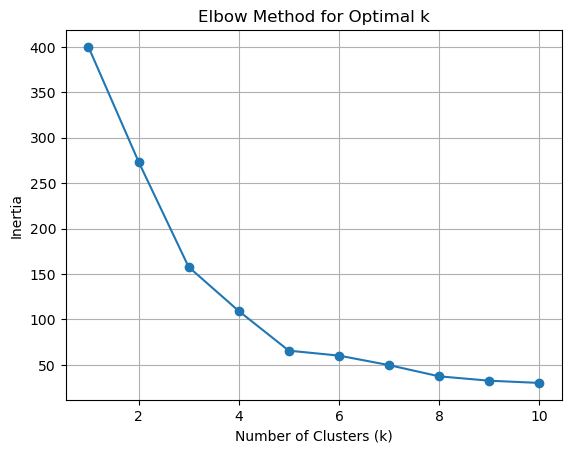

In [64]:
from sklearn.cluster import KMeans
# Elbow method to find optimum k value
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.grid()
plt.show()

In [109]:
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(scaled_data)


C:\Users\anant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=5, random_state=42)

In [110]:
df['Cluster'] = kmeans.labels_
print(df['Cluster'])

0      4
1      2
2      4
3      2
4      4
      ..
195    1
196    3
197    1
198    3
199    1
Name: Cluster, Length: 200, dtype: int32


In [112]:
#here we form 3 cluster and datapints are assigned to different clusters

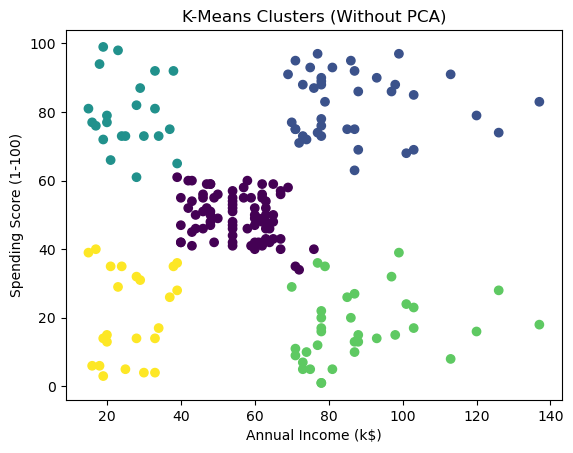

In [113]:
plt.scatter(df.iloc[:,0], df.iloc[:,1], c=df['Cluster'])
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.title("K-Means Clusters (Without PCA)")
plt.show()


In [114]:
cluster_0 = df[df['Cluster'] == 0]
cluster_1 = df[df['Cluster'] == 1]
cluster_2 = df[df['Cluster'] == 2]   # only if k=3


In [115]:
print(cluster_0.head())
print(cluster_1.head())
print(cluster_2.head())


    Annual Income (k$)  Spending Score (1-100)  Cluster
43                  39                      61        0
46                  40                      55        0
47                  40                      47        0
48                  40                      42        0
49                  40                      42        0
     Annual Income (k$)  Spending Score (1-100)  Cluster
123                  69                      91        1
125                  70                      77        1
127                  71                      95        1
129                  71                      75        1
131                  71                      75        1
   Annual Income (k$)  Spending Score (1-100)  Cluster
1                  15                      81        2
3                  16                      77        2
5                  17                      76        2
7                  18                      94        2
9                  19                      72  

In [116]:
#arranged each cluster as a dataframe

In [117]:
from sklearn.metrics import silhouette_score
labels = kmeans.fit_predict(scaled_data)  

C:\Users\anant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [118]:
sil_score = silhouette_score(scaled_data, labels)
print("Silhouette Score:", sil_score)

Silhouette Score: 0.5546571631111091
